<a href="https://colab.research.google.com/github/nngiabao/AIDevFundamental/blob/main/FreshRottenFruit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#link: https://www.kaggle.com/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images

In [ ]:
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d abdulrafeyyashir/fresh-vs-rotten-fruit-images

Dataset URL: https://www.kaggle.com/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images
License(s): apache-2.0
  0% 0.00/38.5M [00:00<?, ?B/s]
100% 38.5M/38.5M [00:00<00:00, 2.39GB/s]


In [ ]:
#unzip file
!unzip fresh-vs-rotten-fruit-images.zip -d fruit_images


Archive:  fresh-vs-rotten-fruit-images.zip
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (1).jpg  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (1).png  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (1).webp  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (100).jpg  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (101).jpg  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (102).jpg  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (103).jpg  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (104).jpg  
  inflating: fruit

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [ ]:
path = '/content/fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset'
os.listdir(path)

['Apple', 'Banana', 'Strawberry']

In [ ]:
strawberry_path = os.path.join(path, 'Strawberry')
apple_path = os.path.join(path, 'Apple')
banana_path = os.path.join(path, 'Banana')

print(f"Strawberry directory: {strawberry_path}")
print(f"Apple directory: {apple_path}")
print(f"Banana directory: {banana_path}")

Strawberry directory: /content/fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Strawberry
Apple directory: /content/fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple
Banana directory: /content/fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Banana


In [ ]:
#labels
labels = []
images = []

fruit_types = os.listdir(path)

for fruit_type in fruit_types:
    fruit_dir = os.path.join(path, fruit_type)

    if os.path.isdir(fruit_dir):
      freshness_types = os.listdir(fruit_dir)

      for freshness_type in freshness_types:
          freshness_dir = os.path.join(fruit_dir, freshness_type)

          if os.path.isdir(freshness_dir):
             for image_filename in os.listdir(freshness_dir):
                 if image_filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_path = os.path.join(freshness_dir, image_filename)
                    images.append(image_path)
                    labels.append(freshness_type)

print(f"Collected {len(images)} images and {len(labels)} labels.")

Collected 529 images and 529 labels.


In [ ]:
df = pd.DataFrame({'image_path': images, 'label': labels})
df.head()

,image_path,label
0,/content/fruit_images/Fruit Freshness Dataset/...,Rotten
1,/content/fruit_images/Fruit Freshness Dataset/...,Rotten
2,/content/fruit_images/Fruit Freshness Dataset/...,Rotten
3,/content/fruit_images/Fruit Freshness Dataset/...,Rotten
4,/content/fruit_images/Fruit Freshness Dataset/...,Rotten


Text(0.5, 0, 'Label')

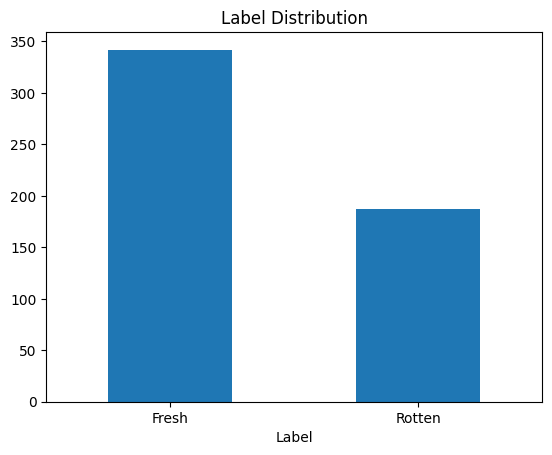

In [ ]:
df['label'].value_counts(ascending=False).plot(kind='bar', title='Label Distribution')
plt.xticks(rotation=0)
plt.xlabel('Label')

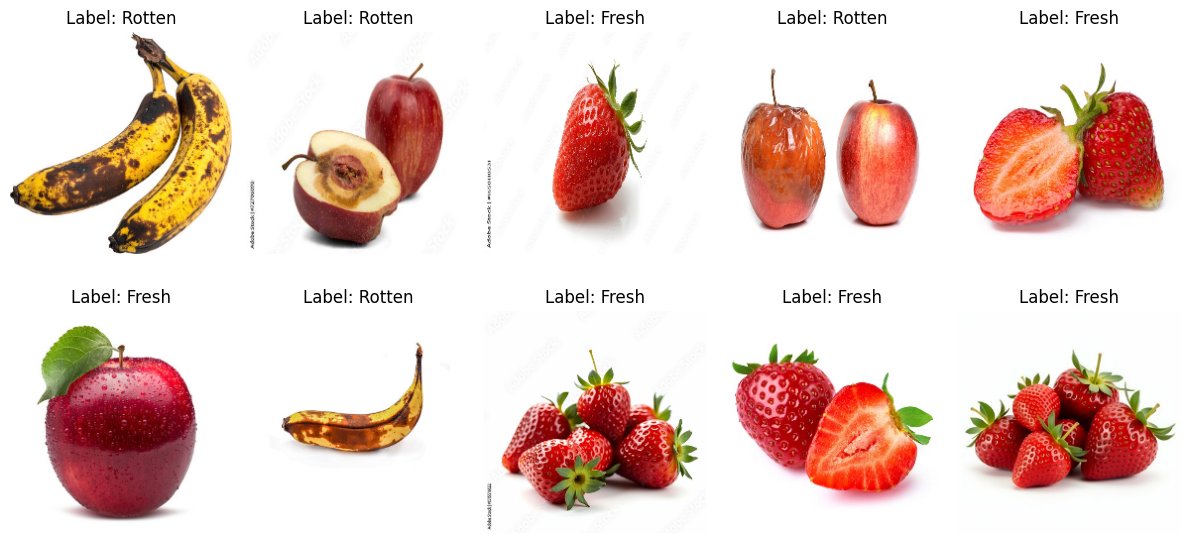

In [ ]:
import cv2
labels = df['label'].unique()

plt.figure(figsize=(12, 6))

for i in range(10):
  random_index = random.randint(0, len(df) - 1)
  image_path = df.iloc[random_index]['image_path']
  label = df.iloc[random_index]['label']

  img = plt.imread(image_path).copy()
  resized_img = cv2.resize(img, (224, 224))
  plt.subplot(2, 5, i+1)
  plt.imshow(resized_img)
  plt.title(f"Label: {label}")
  plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#preparing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['image_path'], df['label'], test_size=0.2, random_state=42)

train_df = pd.DataFrame({'image_path': X_train, 'label': y_train})
test_df = pd.DataFrame({'image_path': X_test, 'label': y_test})

In [ ]:
train_df.head()

,image_path,label
137,/content/fruit_images/Fruit Freshness Dataset/...,Fresh
525,/content/fruit_images/Fruit Freshness Dataset/...,Fresh
416,/content/fruit_images/Fruit Freshness Dataset/...,Fresh
371,/content/fruit_images/Fruit Freshness Dataset/...,Fresh
69,/content/fruit_images/Fruit Freshness Dataset/...,Fresh


In [ ]:
train_df.shape

(423, 2)

# Data processing